In [8]:
# Импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.inspection import permutation_importance
from tensorflow import keras
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
import numpy as np

# 📊 EDA и ресерч-анализ

In [34]:
data = pd.read_csv("dataset.csv")
data = data.drop(["Unnamed: 0", "track_id"], axis=1)#сразу убираем столбец ID, так как он не поможет в решении задачи (не несет полезной метрики)
data

,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music




Расшифруем атрибуты табилцы:

    track_id: Уникальный идентификатор трека
    artists: Автор трека
    album_name: Название альбома (трека, если это сингл)
    track_name: Название трека
    popuarity: Численная мера популярности
    duration_ms: Длительность трека в милисекундах
    explicit: Флаг, указывающий на возрастные ограничения
    danceability: Условный показатель, отражающий степень "танцевальности" трека
    energy: Условный показатель, отражающий степень энергичности трека
    key: Тональность
    loudness: Громкость трек в децибелах
    mode: Модальность трека (0 — минор, 1 — мажор)
    speechiness: Флаг, указывающий на наличие слов в треке
    acousticness: Условный показатель, отражающий степень акустичности трека
    instrumentalness: Условный показатель, отражающий степень инструментальности трека
    liveness: Условный показатель, отражающий степень живости (?) трека
    valence: Условный показатель, отражающий эмоциональную позитивность трека
    tempo: Темп трека
    time_signature: Размерность трека
    track_genre: Жанр трека



In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   artists           113999 non-null  object 
 1   album_name        113999 non-null  object 
 2   track_name        113999 non-null  object 
 3   popularity        114000 non-null  int64  
 4   duration_ms       114000 non-null  int64  
 5   explicit          114000 non-null  bool   
 6   danceability      114000 non-null  float64
 7   energy            114000 non-null  float64
 8   key               114000 non-null  int64  
 9   loudness          114000 non-null  float64
 10  mode              114000 non-null  int64  
 11  speechiness       114000 non-null  float64
 12  acousticness      114000 non-null  float64
 13  instrumentalness  114000 non-null  float64
 14  liveness          114000 non-null  float64
 15  valence           114000 non-null  float64
 16  tempo             11

In [35]:
#Оценка пропусков df
data.isnull().sum()

,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0
key,0
loudness,0


In [36]:
# Выводим строки, имеющие отсутствующие значения
data[data.isnull().any(axis=1)]

,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,NaN,NaN,NaN,0,0,False,0.501,0.583,7,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


Можем заметить одну некорректную строку, поэтому можем полностью избавиться от неё:

In [37]:
data = data.dropna()

# Первичная аналитика данных и работа с атрибутами, проверка гипотез

### 1. Общая статистика

Для начала посмотрим распределение треков по популярности

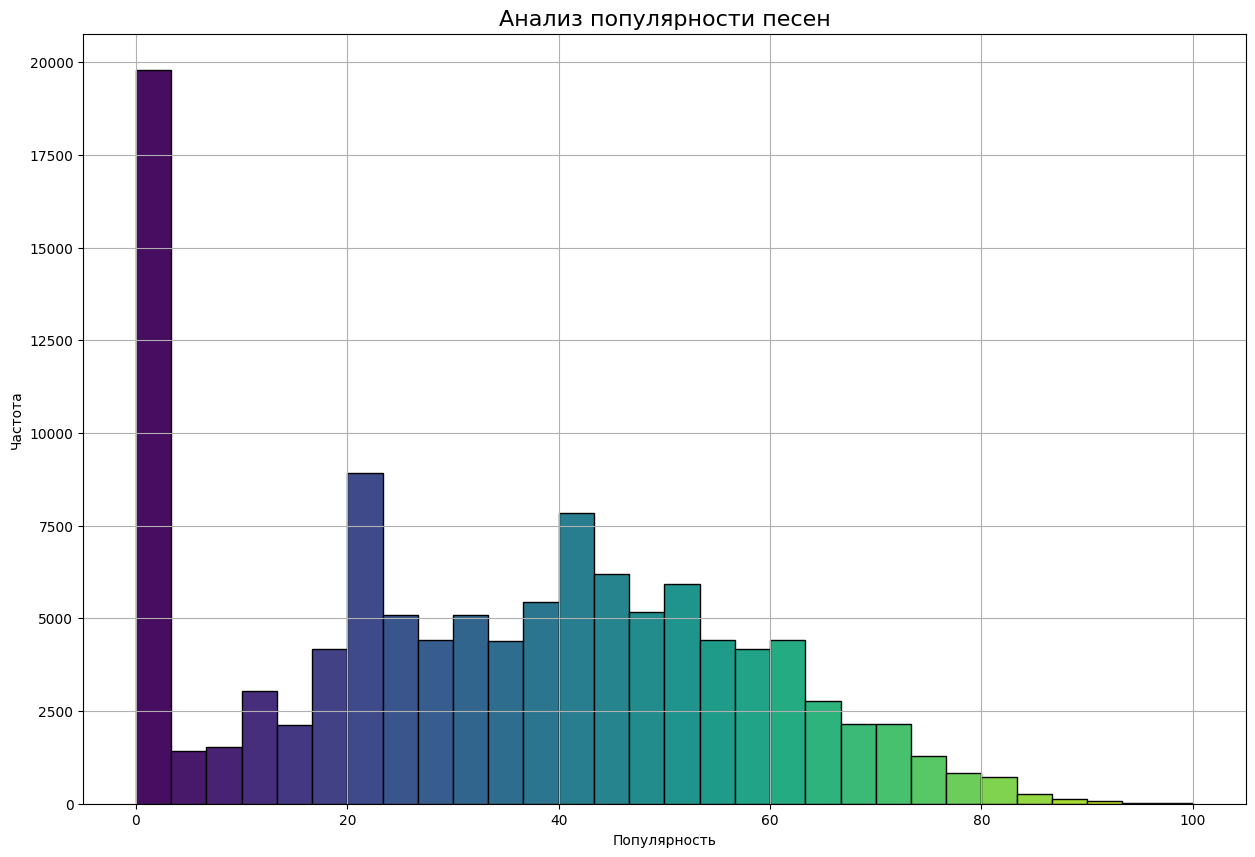

Средняя популярность: 33.24


In [9]:
# Подготовка данных
values = data['popularity'].dropna()
counts, bins = np.histogram(values, bins=30)

# Цвета из палитры viridis
colors = sns.color_palette("viridis", len(bins) - 1)

# Рисуем вручную каждый столбик с градиентом
plt.figure(figsize=(15, 10))
for i in range(len(bins) - 1):
    plt.bar(
        bins[i],
        counts[i],
        width=bins[i + 1] - bins[i],
        color=colors[i],
        align='edge',
        edgecolor='black'
    )

# Оформление графика
plt.title('Анализ популярности песен', fontsize=16)
plt.xlabel('Популярность')
plt.ylabel('Частота')
plt.grid(True)
plt.show()

print(f'Средняя популярность: {values.mean():.2f}')

Можем отметить немалое количество треков с нулевой популярностью, так же заметны скачки в пределах 20-22

### 2. Гипотеза о жанрах

Интуитивно понятно, что какие то жанры могут слушать намного чаще, чем другие, сейчас проверим это:

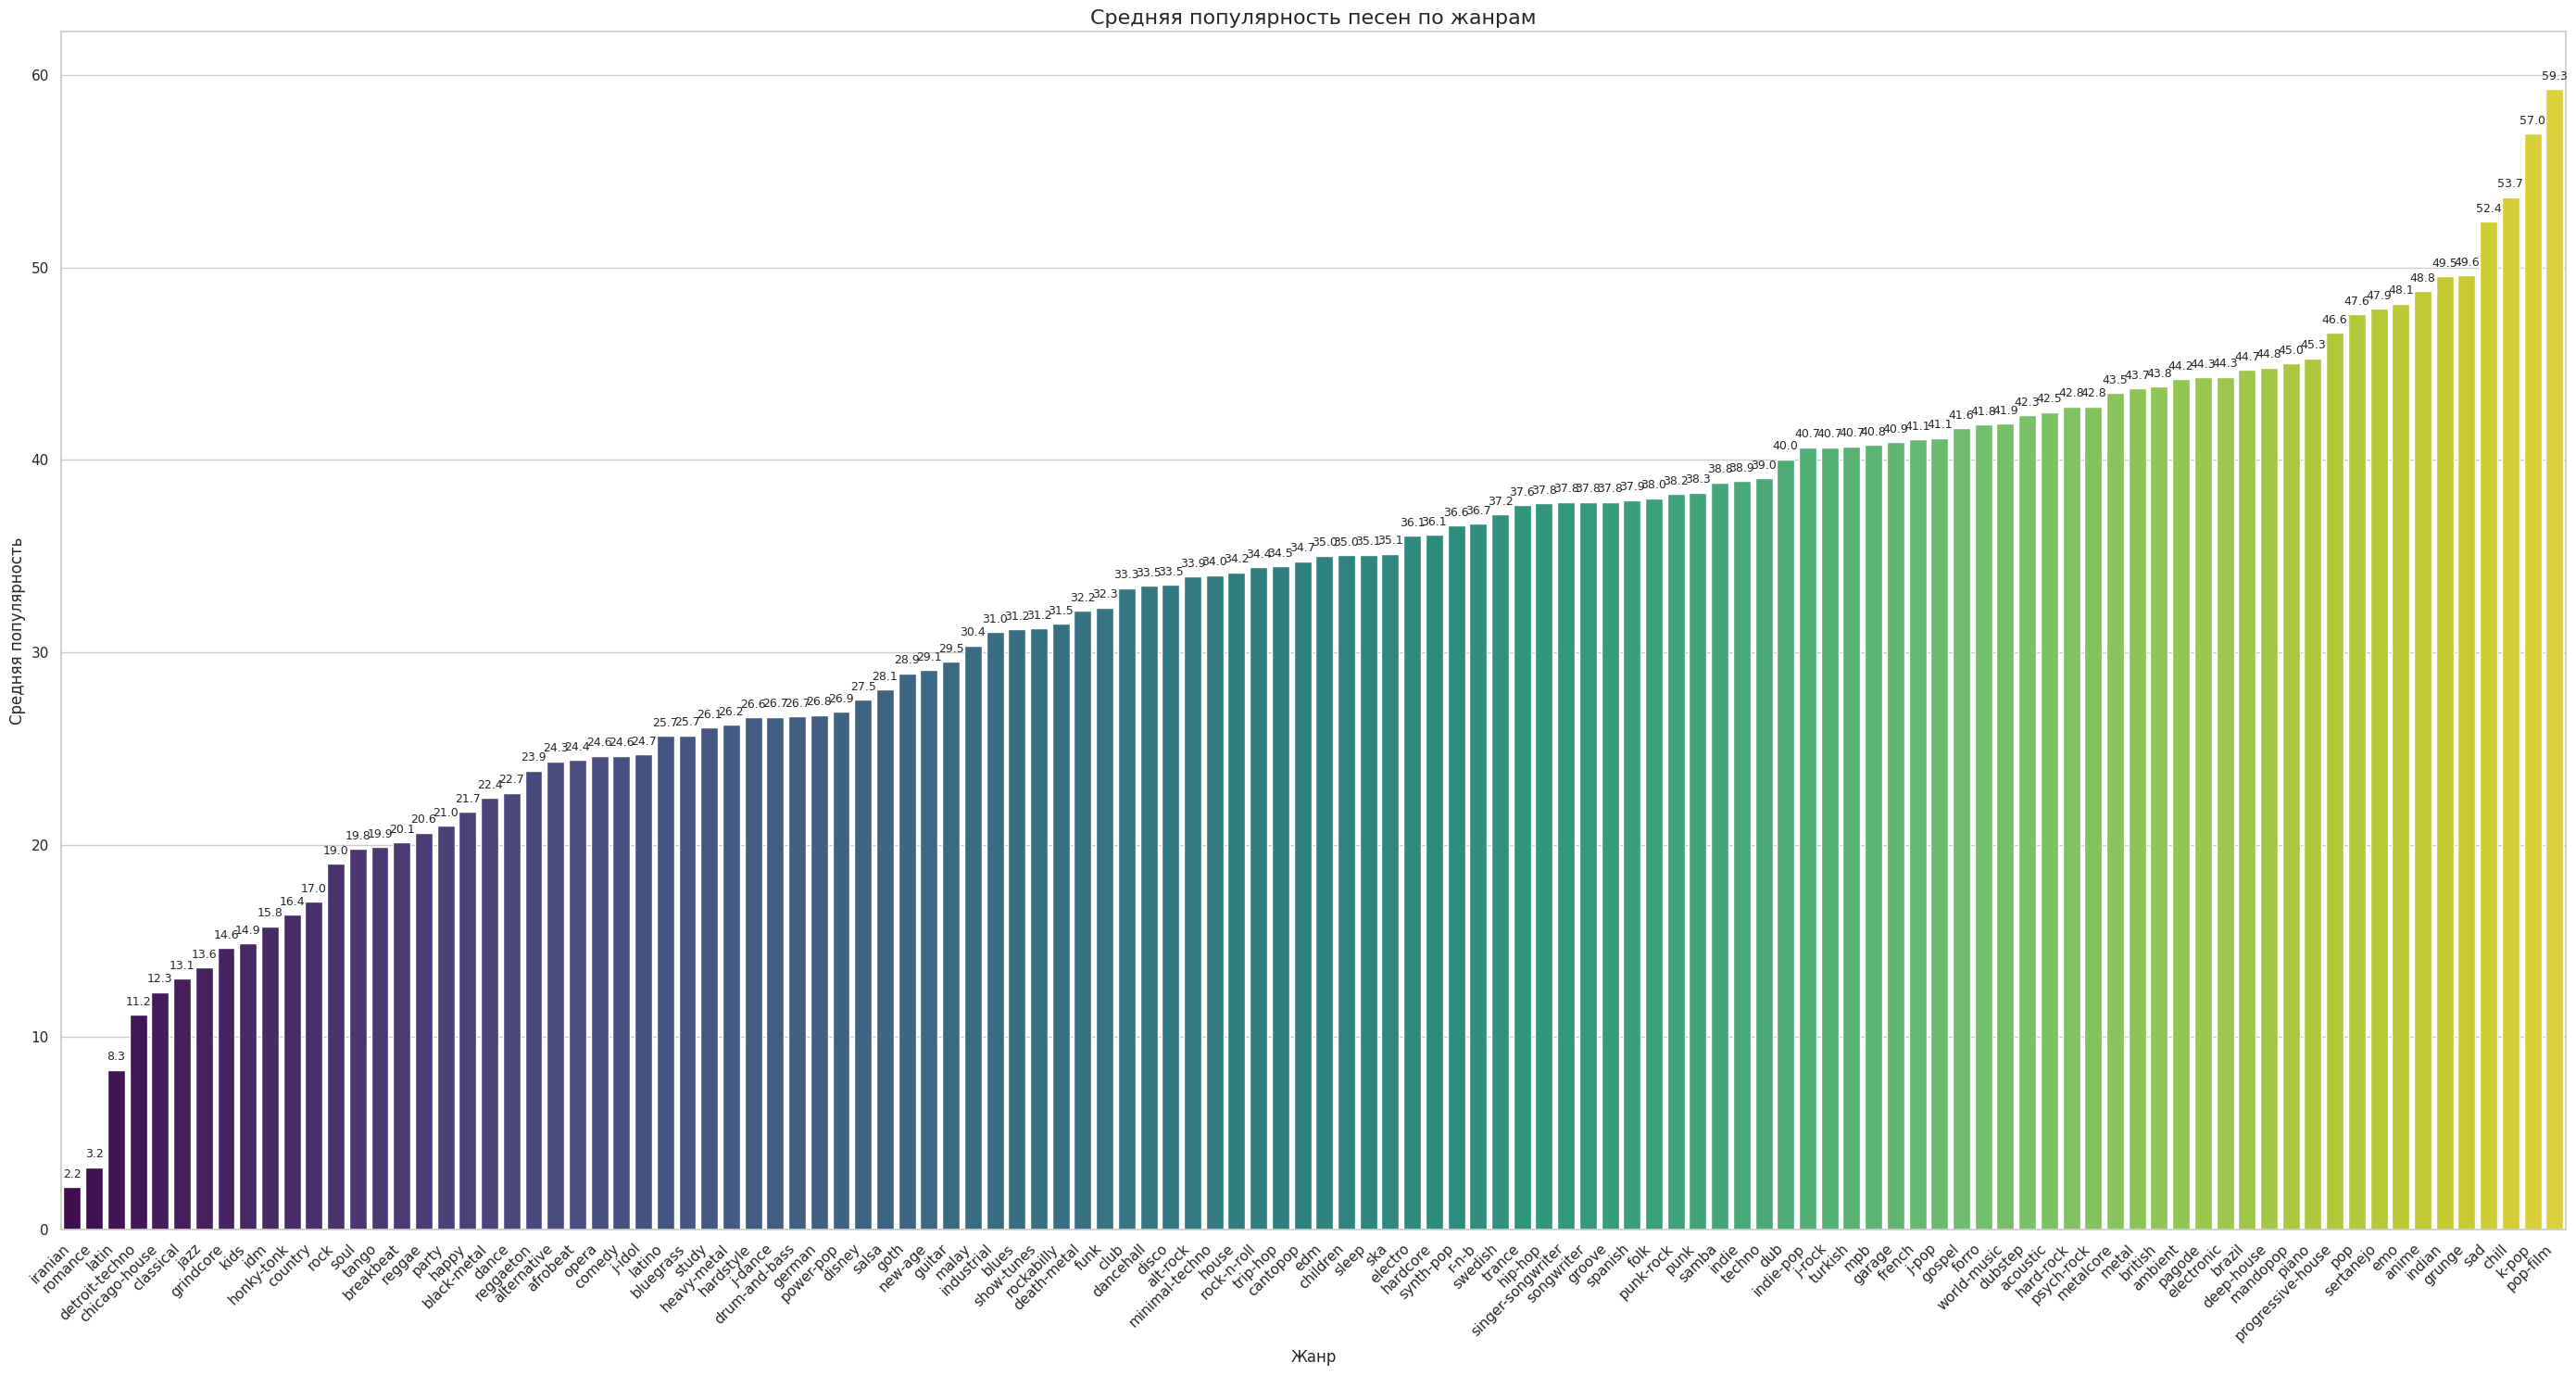

In [10]:
# Подготовка данных
average_popularity = data.groupby('track_genre')['popularity'].mean().reset_index()
average_popularity.columns = ['Жанр', 'Средняя популярность']
average_popularity = average_popularity.sort_values(by='Средняя популярность')

# Установка стиля
sns.set(style="whitegrid")

# Создание градиентной палитры
num_bars = len(average_popularity)
colors = sns.color_palette("viridis", num_bars)

# Добавляем столбец с цветами (не обязательно, но удобно)
average_popularity['color'] = colors

# Построение графика: передаём цвета через параметр `color`, без palette
plt.figure(figsize=(28, 15))
barplot = sns.barplot(
    data=average_popularity,
    x='Жанр',
    y='Средняя популярность',
    hue='Жанр',
    palette=dict(zip(average_popularity['Жанр'], colors)),
)

# Поворот подписей с использованием plt.xticks
plt.xticks(rotation=45, ha='right')

# Добавим значения над столбцами
for i, row in enumerate(average_popularity.itertuples()):
    plt.text(i, row._2 + 0.5, f"{row._2:.1f}", ha='center', fontsize=9)

# Оформление
plt.title('Средняя популярность песен по жанрам', fontsize=16)
plt.xlabel('Жанр')
plt.ylabel('Средняя популярность')
plt.tight_layout()
plt.show()

Как видим, жанр действительно сильно влияет на популярность прослушивания, что и было очевидно.

Наиболее популярны:
* pop
* k-pop
* chill

Наименее популярны:
* iranian
* romance
* latin

### 3. Гипотеза об артистах

Аналогично жанру, какой то артист может быть в топе и иметь много прослушиваний, в то время как другой быть внизу

Однако в датасете может быть оооочень много артистов, поэтому посмотрим топ 30

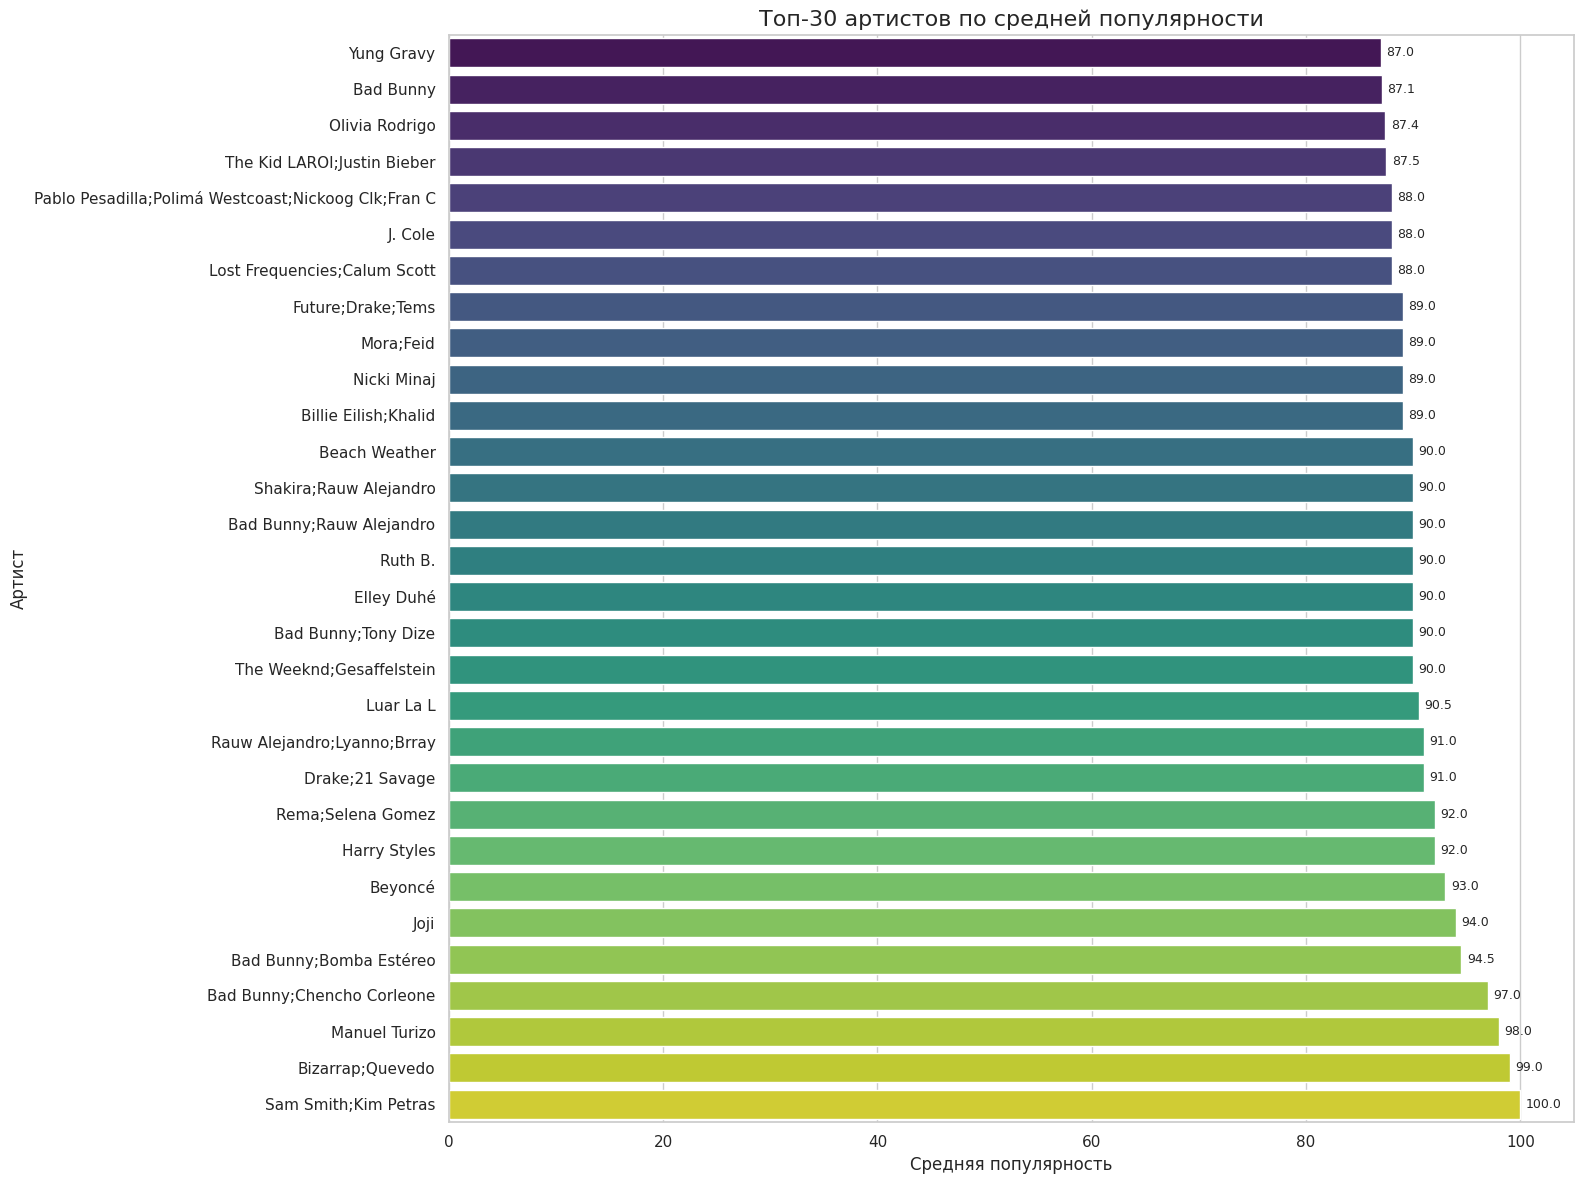

In [11]:
# Группировка по артистам и расчёт средней популярности
average_artist_popularity = data.groupby('artists')['popularity'].mean().reset_index()
average_artist_popularity.columns = ['Артист', 'Средняя популярность']

# Отбираем топ-30 самых популярных артистов
top_artists = average_artist_popularity.sort_values(by='Средняя популярность', ascending=False).head(30)
top_artists = top_artists.sort_values(by='Средняя популярность')  # для аккуратной горизонтальной сортировки

# Создание градиентной палитры
num_bars = len(top_artists)
colors = sns.color_palette("viridis", num_bars)
top_artists['color'] = colors

# Установка стиля
sns.set(style="whitegrid")

# Построение графика
plt.figure(figsize=(16, 12))
barplot = sns.barplot(
    data=top_artists,
    y='Артист',
    x='Средняя популярность',
    hue='Артист',
    palette=dict(zip(top_artists['Артист'], colors)),
    dodge=False,
    legend=False
)

# Добавление значений в бары
for i, row in enumerate(top_artists.itertuples()):
    plt.text(row._2 + 0.5, i, f"{row._2:.1f}", va='center', fontsize=9)

# Оформление
plt.title('Топ-30 артистов по средней популярности', fontsize=16)
plt.xlabel('Средняя популярность')
plt.ylabel('Артист')
plt.tight_layout()
plt.show()

Наша гипотеза подтвердилась даже не на полной выборке

### 4. Зависимость длительности песни от ее популярности

А что если большинство отдает предпочтение определенной длительности песен?
Добавим новый столбец, чтобы было легче визуализировать данные

In [ ]:
# Добавляем столбец длительности в минутах
data["duration_min"] = data.duration_ms / 1000 / 60
# Удаляем столбец длительности в миллисекундах
data = data.drop("duration_ms", axis=1)

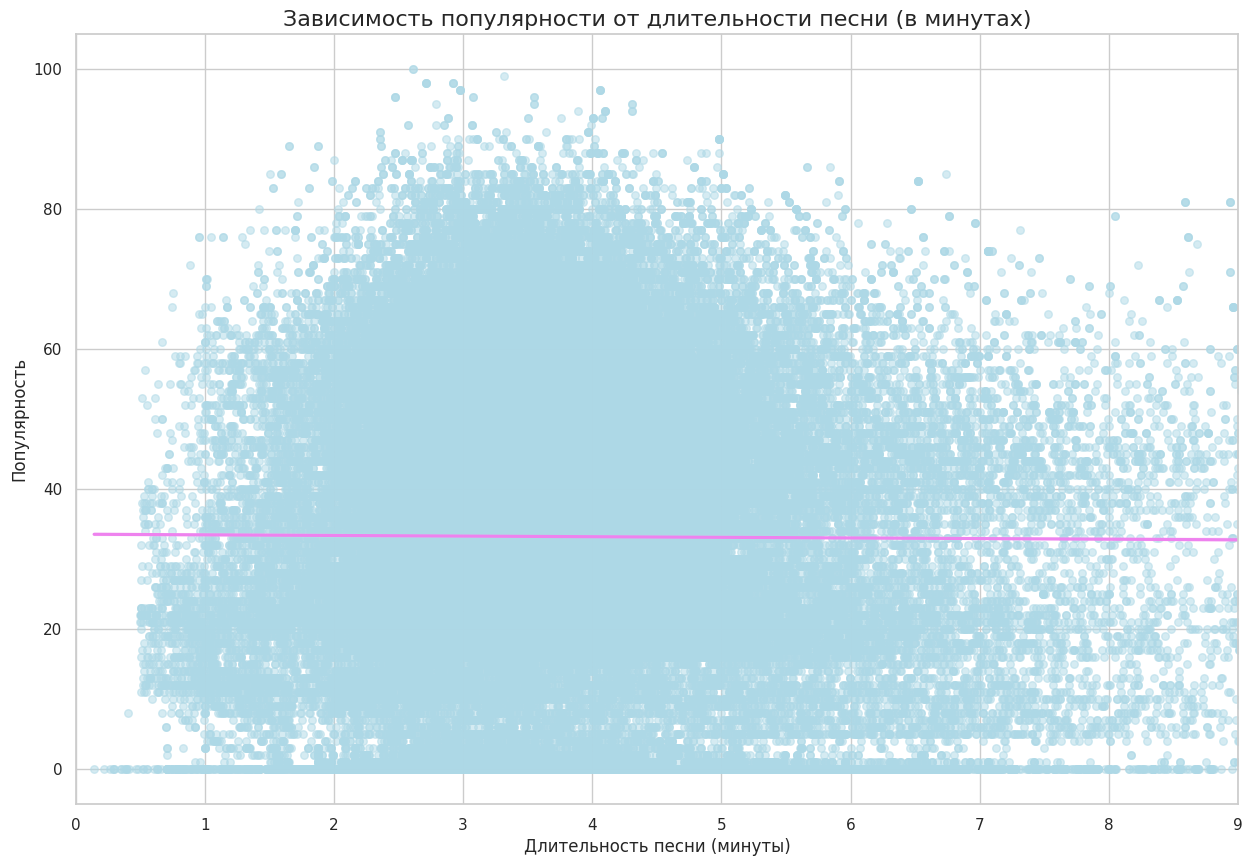

In [14]:
plt.figure(figsize=(15, 10))

# Диаграмма рассеяния с линией регрессии
sns.regplot(
    data=data,
    x='duration_min',
    y='popularity',
    scatter_kws={'alpha': 0.5, 's': 30, 'color': 'lightblue'},
    line_kws={'color': 'violet'}
)

plt.xlim(0, 9)

plt.title('Зависимость популярности от длительности песни (в минутах)', fontsize=16)
plt.xlabel('Длительность песни (минуты)')
plt.ylabel('Популярность')
plt.grid(True)
plt.show()

Как видим наиболее популярны треки в диапазоне от 2 до 6 минут.

### 5.  Зависимость популярности от наличия слов в песне

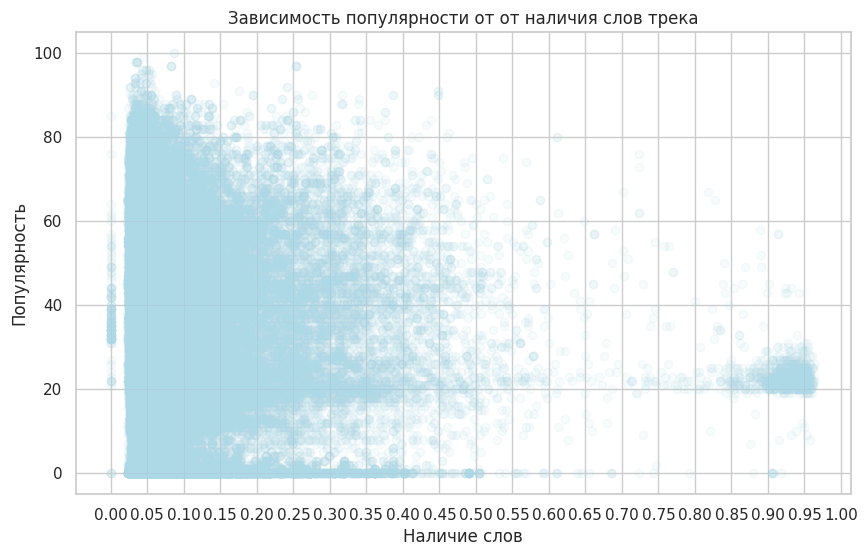

In [15]:
plt.figure(figsize=(10, 6))
plt.scatter(data['speechiness'], data['popularity'], alpha=0.1, color='lightblue')

# Настройка делений по оси X с шагом 0.05
plt.xticks(np.arange(0, 1.05, 0.05))

plt.title("Зависимость популярности от от наличия слов трека")
plt.xlabel("Наличие слов")
plt.ylabel("Популярность")
plt.grid(True)
plt.show()

Неочевидные показатели: оказывается, что наиболее популярны треки, в которых меньше слов (коэффициент speechiness для популярных треков лежит в диапозоне от 0.02 до 0.25)

### 6. Зависимость популярности музыки от позитивности

А что если людям нравится слушать позитивные треки, больше чем меланхоличные?
Для этого анализа сначала найдем среднее по палате, а потом уже опираясь на это значение будем относить трек к классу позитивный или негативный в эмоиональном плане:

<ipython-input-16-6a8570d91490>:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


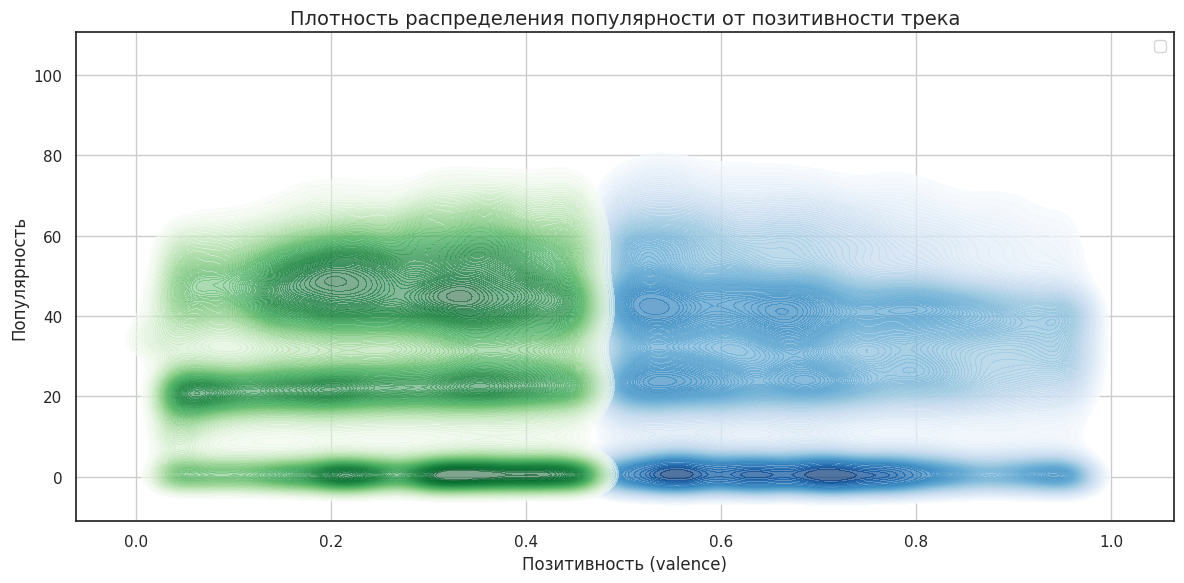

In [16]:
avg_valence = sum([i for i in data['valence']])/len([i for i in  data['valence']])
# Разделим данные
positive = data[data['valence'] >= avg_valence]
negative = data[data['valence'] <  avg_valence]

# Устанавливаем стиль
sns.set(style="white", palette="muted")

# Создаём фигуру
plt.figure(figsize=(12, 6))

# Строим KDE для позитивных треков
sns.kdeplot(
    data=positive,
    x="valence", y="popularity",
    fill=True,
    cmap="Blues",
    thresh=0.05,
    levels=100,
    alpha=0.7,
    label="Позитивные"
)

# Строим KDE для негативных треков
sns.kdeplot(
    data=negative,
    x="valence", y="popularity",
    fill=True,
    cmap="Greens",
    thresh=0.05,
    levels=100,
    alpha=0.5,
    label="Негативные"
)

# Оформление
plt.title("Плотность распределения популярности от позитивности трека", fontsize=14)
plt.xlabel("Позитивность (valence)")
plt.ylabel("Популярность")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

По графику видим, что совсем немного лидируют песни с негативной эмоциональной окраской

### 7. Популярности песен, название которых совпадает с названием альбом

Часто песни, на которых базируется альбом - являются популярными

Проверим:

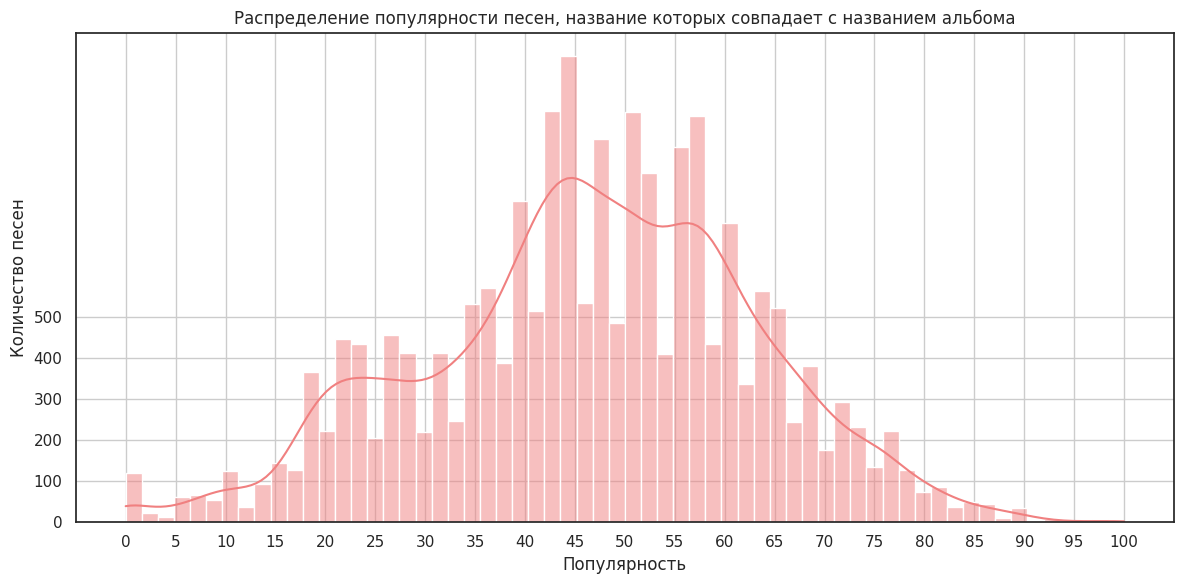

In [17]:
# Отбираем треки, название которых совпадает с названием альбома
track_is_album = data[data['track_name'] == data['album_name']]

plt.figure(figsize=(12, 6))

# График распределения
sns.histplot(data=track_is_album, x='popularity', kde=True, color='lightcoral')

# Заголовки и подписи
plt.title('Распределение популярности песен, название которых совпадает с названием альбома')
plt.xlabel('Популярность')
plt.ylabel('Количество песен')

plt.xticks(np.arange(0, 105, 5))  # шаг 5 от 0 до 100

# Увеличиваем деления по оси Y в зависимости от высоты гистограммы
max_count = track_is_album['popularity'].value_counts().max()
plt.yticks(np.arange(0, max_count + 5, 100))  # шаг 2

plt.grid(True)
plt.tight_layout()
plt.show()

Песни, названия которых совпадают с названием альбома, имеют большее среднее значение популярности и стабильно распределены (с более ровной "колоколообразной" формой относительно первой гипотезы)

### Матрица корреляции

Поскольку мы имеем куда большее количество атрибутов, по сравнению с датасетом Титаник, проверять гипотезы можно очень долго, поэтому проверим напрямую зависимость по популярности от каждого из атрибутов

---

Сперва нам потребуется немного подкорректировать имеющиеся атрибуты для удобной работы:

In [40]:
# Переведём булевый формат атрибута в целочисленный
data['explicit'] = data['explicit'].astype('int64')

# Выделяем столбцы с нечисловыми типами данных
categorical_cols = data.select_dtypes(include=["object"]).columns
label_encoders = {}

# Кодируем их значения с помощью LabelEncoder
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

In [41]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113999 entries, 0 to 113999
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   artists           113999 non-null  int64  
 1   album_name        113999 non-null  int64  
 2   popularity        113999 non-null  int64  
 3   explicit          113999 non-null  int64  
 4   danceability      113999 non-null  float64
 5   energy            113999 non-null  float64
 6   key               113999 non-null  int64  
 7   loudness          113999 non-null  float64
 8   mode              113999 non-null  int64  
 9   speechiness       113999 non-null  float64
 10  acousticness      113999 non-null  float64
 11  instrumentalness  113999 non-null  float64
 12  liveness          113999 non-null  float64
 13  valence           113999 non-null  float64
 14  tempo             113999 non-null  float64
 15  time_signature    113999 non-null  int64  
 16  track_genre       113999 

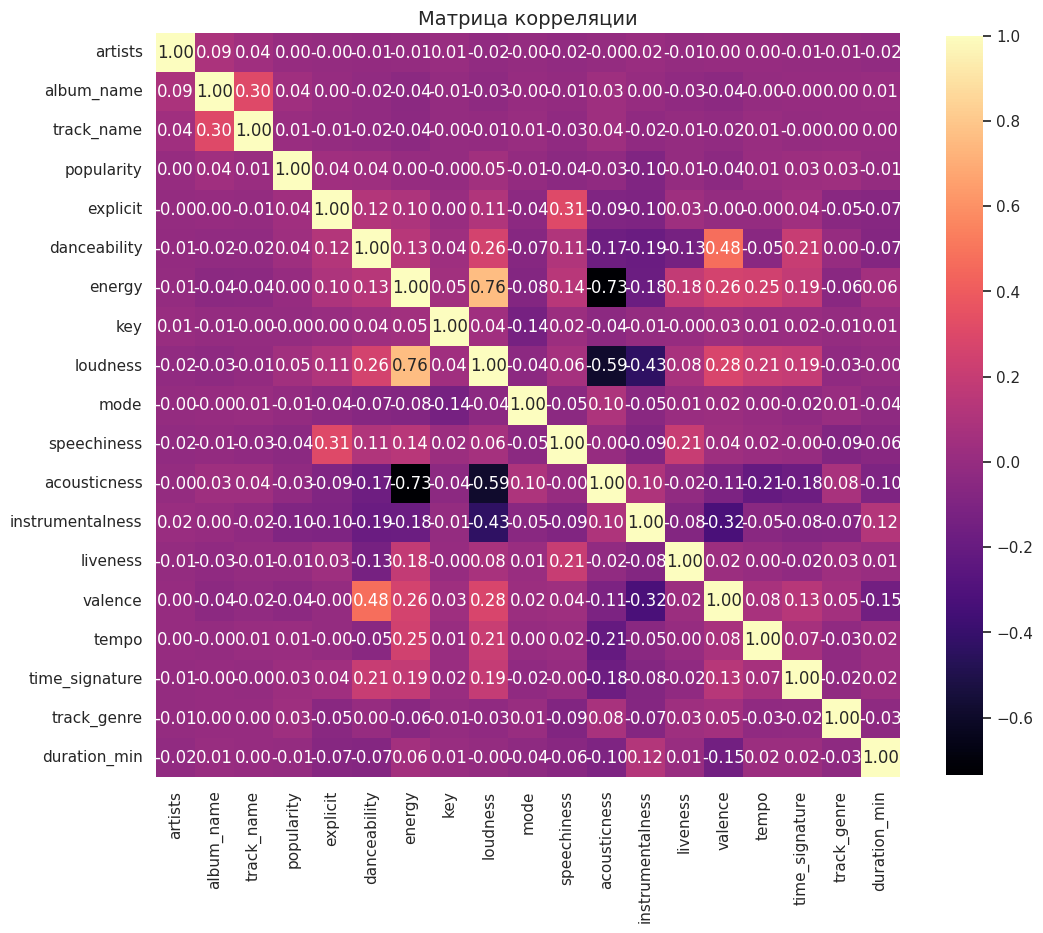

In [23]:
# Выбор числовых признаков
numerical_features = data.select_dtypes(include=['number']).columns.tolist()
correlation_matrix = data[numerical_features].corr()

# Построение тепловой карты
plt.figure(figsize=(12, 12))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap='magma',
    square=True,
    cbar_kws={"shrink": .8}
)
plt.title("Матрица корреляции", fontsize=14)
plt.show()

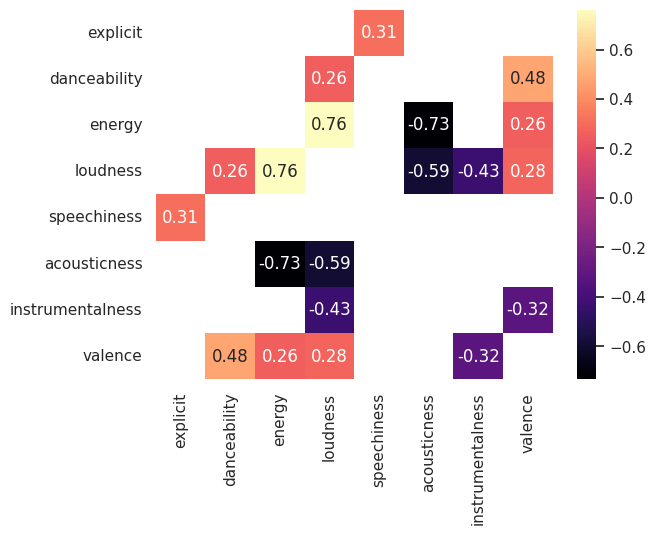

In [28]:
# Фильтруем значения корреляции и скрываем полностью пустые линии на обеих осях
corr = data.corr()
corr = corr[(corr.abs() > 0.25) & (corr < 1)].dropna(how="all").dropna(how="all", axis=1)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="magma")
plt.show()

Самые взаимозависимые признаки:


```
danceability: loudness (0.26), valence (0.48), time_signature (0.21)
energy: acousticness (-0.73), loudness (0.76), valence (0.26), tempo (0.25)
loudness: acousticness (-0.59), instrumentalness (-0.43), valence (0.28), tempo (0.21)
speechness: liveness (0.21)
acousticness: tempo (-0.21)
instrumentalness: valence (-0.32)
```



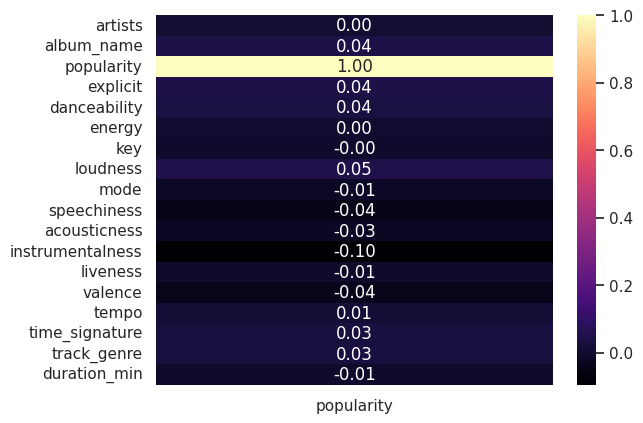

In [31]:
# Берём только столбец популярности (Series) и переводим его в DataFrame
sns.heatmap(data.corr().popularity.to_frame(), annot=True, fmt=".2f", cmap="magma")
plt.show()

Однако popularity не показывает прямо таки сильной корреляции не с одним из атрибутов, разве что с инструментальностью

### 👨‍💻 Feature Engineering
По проделанное ранее работе можем приступить к этапу Fetaure Engineering, где предстоит добавить новые признаки и избавиться от неинформативных.

Так как мы выяснили, что основной трек альбома зачастую имеет высшую популярность, выведем его в отдельный атрибут:

In [39]:
# Добавляем столбец главной песни альбома
data["main_track"] = data.track_name == data.album_name
# Удаляем столбец названия песни
data = data.drop("track_name", axis=1)

In [43]:
data.main_track = data.main_track.astype(int)

Избавимся от нулевых значений popularity, чтобы избежать возможных аномалий:

In [69]:
data = data[data.popularity != 0]

### Простая модель

Создадим тестовую модель на основе нейронной сети, чтобы узнать, как разные признаки влияют на точность предсказания

In [65]:
# Делим данные на обучающую и тестовую выборки
X = data.drop(columns=["popularity"])
y = data["popularity"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [66]:
# Стандартизируем данные
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Epoch 1/10
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 544.3870 - val_loss: 327.8142
Epoch 2/10
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 323.3346 - val_loss: 325.5132
Epoch 3/10
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 316.6627 - val_loss: 322.1902
Epoch 4/10
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 312.6880 - val_loss: 312.6802
Epoch 5/10
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 305.1646 - val_loss: 307.3883
Epoch 6/10
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 298.4403 - val_loss: 305.9876
Epoch 7/10
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 295.0535 - val_loss: 303.3453
Epoch 8/10
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 295.5186 - val_loss: 303.6675
Epoch 9/10
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 292.6679 - val_loss: 301.6147
Epoch 10/10
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 288.3118 - val_loss: 299.0299
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 303.0199
Test Loss: 303.11212

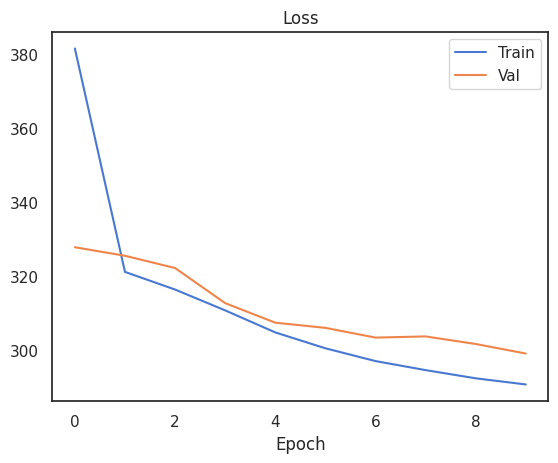

In [67]:
# Собираем модель
model = keras.Sequential([
    keras.layers.Input((X_train.shape[1],)),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(1)
])

# Компилим модель
model.compile(optimizer="adam", loss="mean_squared_error")

# Обучаем модель
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Оцениваем модель
loss = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss}")

# Строим график потерь
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend(["Train", "Val"])
plt.show()

In [68]:
# Прогнозируем на тестовой выборке
y_pred = model.predict(X_test)

# Вычисляем метрики
mae_nn = mean_absolute_error(y_test, y_pred)
mse_nn = mean_squared_error(y_test, y_pred)
rmse_nn = mse_nn ** 0.5
r2_nn = r2_score(y_test, y_pred)
mape_nn = mean_absolute_percentage_error(y_test, y_pred)

print(f"MAE: {mae_nn}")
print(f"MSE: {mse_nn}")
print(f"RMSE: {rmse_nn}")
print(f"R2: {r2_nn}")
print(f"MAPE: {mape_nn}")


613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
MAE: 13.766246795654297
MSE: 303.11212158203125
RMSE: 17.410115495941756
R2: 0.18775618076324463
MAPE: 1.4806464910507202


613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━

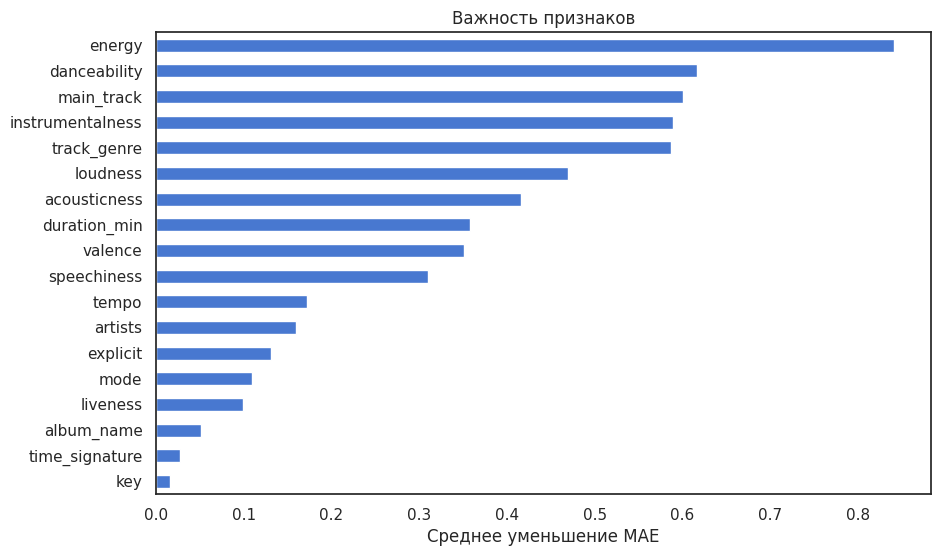

In [70]:
# Важность признаков с помощью permutation importance
result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, scoring="neg_mean_absolute_error")
importances = pd.Series(result.importances_mean, index=X.columns)

# Визуализация важности признаков
importances.sort_values().plot(kind="barh", figsize=(10,6))
plt.title("Важность признаков")
plt.xlabel("Среднее уменьшение MAE")
plt.show()


График показывает, какие признаки и насколько помогают уменьшить среднюю абсолютную ошибку, то есть улучшить точность модели.

---



"За кадром" была совершена попытка выделить признаки "Зависимости популярности от длины трека" и "Популярность жанра трека", но эти признаки слишком сильно влияли на уменьшение MAE и являются производными от popularity, поэтому их использование некорректно.

# Попробуем всё же ввести новые атрибуты

# Длительность

Мы подметили, что песня с большой долью вероятность будет популярной в том случае, если её длительность в диапазоне от 2 до 6 минут, ну или хотя бы не более 8. Создадим новый атрибут, значение которого будет обращаться в 1, если трек меньше 8 минут.

In [71]:
data['dur_8_max'] = data['duration_min'] < 8
data['dur_8_max'] = data['dur_8_max'].astype('int64')

# Инструментальность

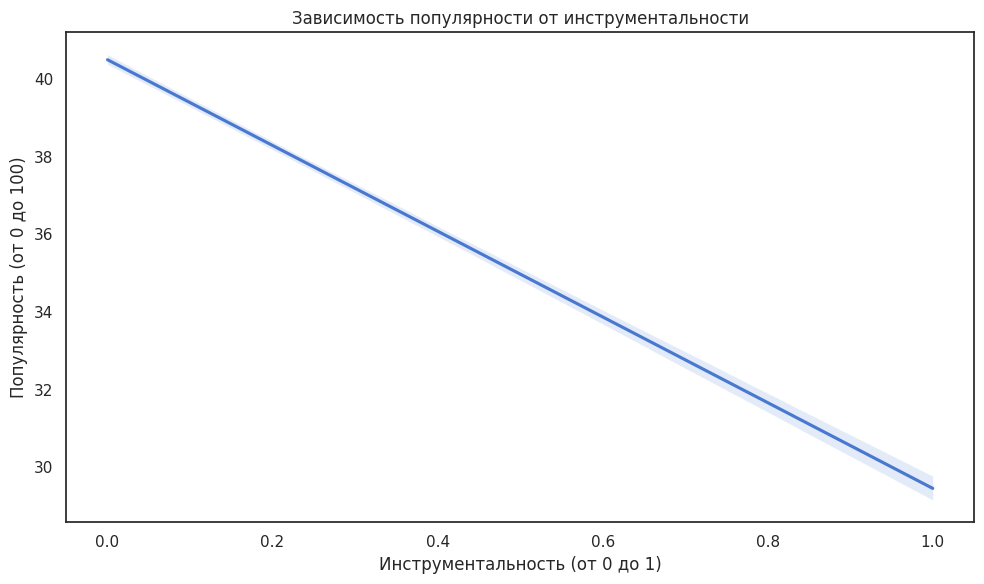

In [74]:
plt.figure(figsize=(10, 6))

# Добавляем линейные регрессию для лучшего представления зависимости
sns.regplot(x='instrumentalness', y='popularity', data=data, scatter=False)

plt.title('Зависимость популярности от инструментальности')
plt.xlabel('Инструментальность (от 0 до 1)')
plt.ylabel('Популярность (от 0 до 100)')

# Отображаем график
plt.tight_layout()
plt.show()

Как ни странно, но чем ниже качество инструментов, тем выше популярность. Со статистикой не поспоришь... Введём признак bad_instrum, принимающий значение 1, когда instrumentalness < 0.5.

In [77]:
data['bad_instrum'] = data['instrumentalness'] < 0.5
data['bad_instrum'] = data['bad_instrum'].astype('int64')

# Громкость

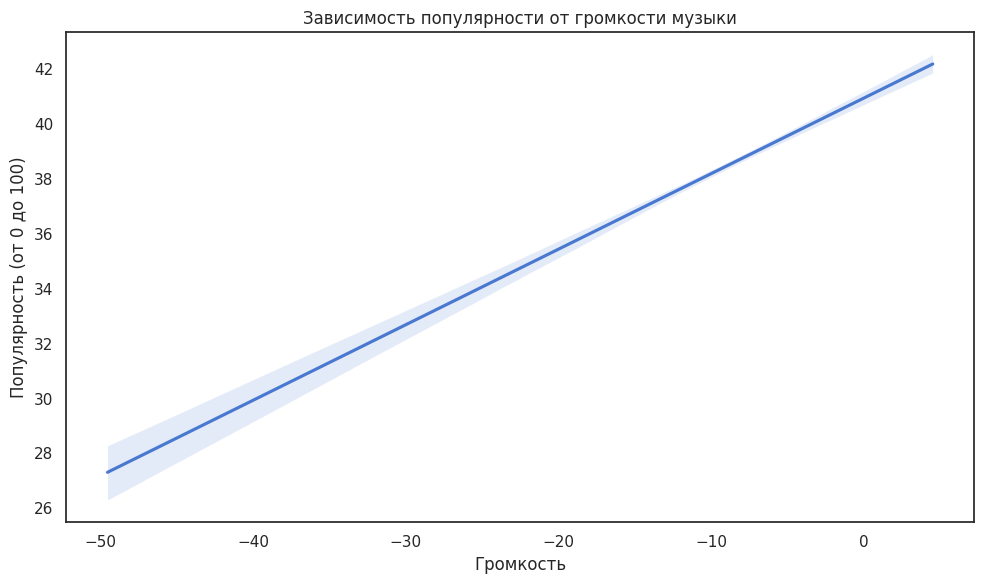

In [75]:
plt.figure(figsize=(10, 6))

# Добавляем линейные регрессию для лучшего представления зависимости
sns.regplot(x='loudness', y='popularity', data=data, scatter=False)

plt.title('Зависимость популярности от громкости музыки')
plt.xlabel('Громкость')
plt.ylabel('Популярность (от 0 до 100)')

# Отображаем график
plt.tight_layout()
plt.show()

Получаем, что чем выше громкость, тем выше популярность. Сделаем флаг = 1, если громкость выше среднего значения:

In [76]:
avg_loudness = sum(data['loudness']) / len(data)
data['high_loudness'] = data['loudness'] >= avg_loudness
data['high_loudness'] = data['high_loudness'].astype('int64')

Теперь проведём нормализацию и заново обучимся:

In [78]:
# Выделяем столбцы с нечисловыми типами данных
categorical_cols = data.select_dtypes(include=["object"]).columns
label_encoders = {}

# Кодируем их значения с помощью LabelEncoder
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

In [79]:
# Делим данные на обучающую и тестовую выборки
X = data.drop(columns=["popularity"])
y = data["popularity"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [80]:
# Стандартизируем данные
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Epoch 1/10
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 539.6982 - val_loss: 326.6384
Epoch 2/10
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 320.2306 - val_loss: 322.6409
Epoch 3/10
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 317.8585 - val_loss: 316.1310
Epoch 4/10
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 309.8328 - val_loss: 312.1501
Epoch 5/10
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 306.9339 - val_loss: 305.9875
Epoch 6/10
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 300.0438 - val_loss: 306.4067
Epoch 7/10
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 298.1583 - val_loss: 301.6416
Epoch 8/10
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 298.7658 - val_loss: 301.0289
Epoch 9/10
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 291.6185 - val_loss: 302.4471
Epoch 10/10
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 294.0268 - val_loss: 298.9326
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 304.4578
Test Loss: 304.529

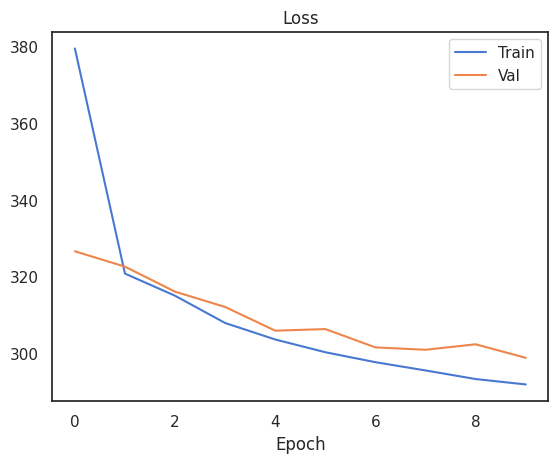

In [81]:
# Собираем модель
model = keras.Sequential([
    keras.layers.Input((X_train.shape[1],)),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(1)
])

# Компилим модель
model.compile(optimizer="adam", loss="mean_squared_error")

# Обучаем модель
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Оцениваем модель
loss = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss}")

# Строим график потерь
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend(["Train", "Val"])
plt.show()

In [82]:
# Прогнозируем на тестовой выборке
y_pred = model.predict(X_test)

# Вычисляем метрики
mae_nn = mean_absolute_error(y_test, y_pred)
mse_nn = mean_squared_error(y_test, y_pred)
rmse_nn = mse_nn ** 0.5
r2_nn = r2_score(y_test, y_pred)
mape_nn = mean_absolute_percentage_error(y_test, y_pred)

print(f"MAE: {mae_nn}")
print(f"MSE: {mse_nn}")
print(f"RMSE: {rmse_nn}")
print(f"R2: {r2_nn}")
print(f"MAPE: {mape_nn}")

613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
MAE: 13.85360336303711
MSE: 304.5290222167969
RMSE: 17.450759932358157
R2: 0.18395936489105225
MAPE: 1.47981858253479


613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
613/613 ━━━━

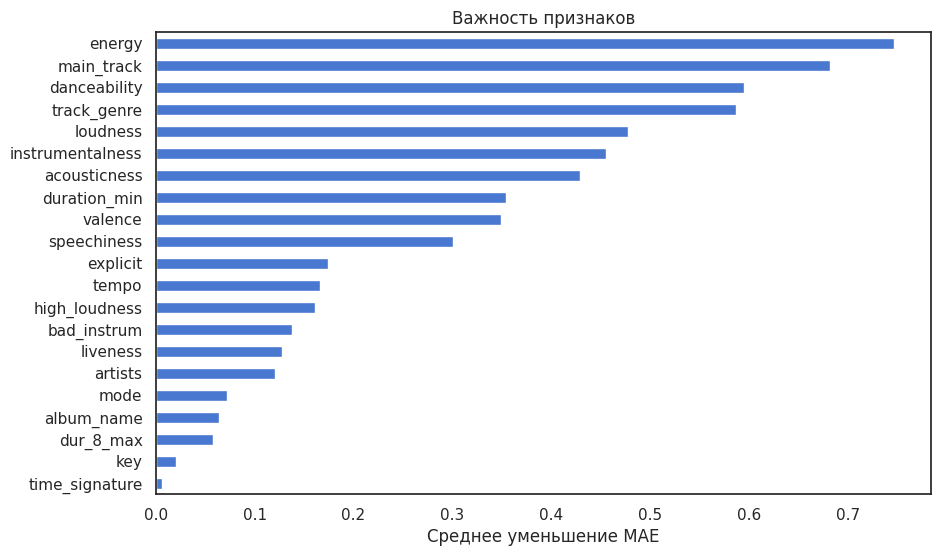

In [83]:
# Важность признаков с помощью permutation importance
result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, scoring="neg_mean_absolute_error")
importances = pd.Series(result.importances_mean, index=X.columns)

# Визуализация важности признаков
importances.sort_values().plot(kind="barh", figsize=(10,6))
plt.title("Важность признаков")
plt.xlabel("Среднее уменьшение MAE")
plt.show()

В ходе Feature Engineering не удалось значительно улучшить обучаемость модели, поэтому придётся работать с тем, что есть. Перед этим я удалю признаки, со значением меньше 0.1:

In [84]:
new_data = data.drop (columns=['dur_8_max', 'time_signature', 'key', 'liveness', 'explicit', 'mode', 'album_name', 'artists'])

### Эксперименты с моделями

### Улучшенная нейронная сеть

Было добавлено количество эпох, добавлен новый слой и изменено количество нейронов.

In [85]:
# Разделим датасет на тренировочный и тестовый выборки:
X = new_data.drop(columns=["popularity"])
y = new_data["popularity"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [86]:
# Стандартизируем данные
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Epoch 1/20
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 508.4012 - val_loss: 335.7152
Epoch 2/20
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 320.2251 - val_loss: 314.3857
Epoch 3/20
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 311.4619 - val_loss: 309.4310
Epoch 4/20
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 308.1718 - val_loss: 317.5246
Epoch 5/20
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 305.8627 - val_loss: 306.7459
Epoch 6/20
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 307.4875 - val_loss: 307.2139
Epoch 7/20
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 299.3900 - val_loss: 303.9842
Epoch 8/20
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 302.1699 - val_loss: 301.8288
Epoch 9/20
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 296.5993 - val_loss: 301.8764
Epoch 10/20
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 296.5829 - val_loss: 299.5742
Epoch 11/20
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 297.7162 - v

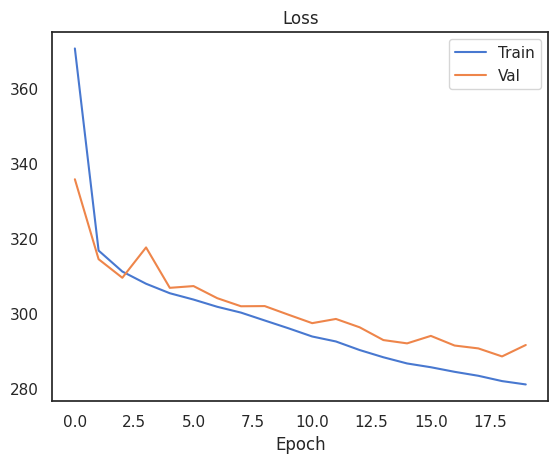

613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
MAE: 13.484844207763672
MSE: 295.7106628417969
RMSE: 17.196239787866325
R2: 0.2075897455215454
MAPE: 1.521957516670227


In [87]:
# Собираем модель
model = keras.Sequential([
    keras.layers.Input((X_train.shape[1],)),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(1)
])

# Компилируем модель
model.compile(optimizer="adam", loss="mean_squared_error")

# Обучаем модель
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Оцениваем модель
loss = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss}")

# Строим график потерь
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend(["Train", "Val"])
plt.show()

# Прогнозируем на тестовой выборке
y_pred = model.predict(X_test)

# Вычисляем метрики
mae_nn = mean_absolute_error(y_test, y_pred)
mse_nn = mean_squared_error(y_test, y_pred)
rmse_nn = mse_nn ** 0.5
r2_nn = r2_score(y_test, y_pred)
mape_nn = mean_absolute_percentage_error(y_test, y_pred)

print(f"MAE: {mae_nn}")
print(f"MSE: {mse_nn}")
print(f"RMSE: {rmse_nn}")
print(f"R2: {r2_nn}")
print(f"MAPE: {mape_nn}")

Попытки изменить ситуацию в лучшую сторону не увенчались успехом. Будем пробовать другую модель.

### Random Forest

In [92]:
# Создаём модель
model = RandomForestRegressor(random_state=42)

# Обучаем модель
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [93]:
# Прогнозируем на тестовой выборке
y_pred = model.predict(X_test)

# Вычисляем метрики
mae_rf = mean_absolute_error(y_test, y_pred)
mse_rf = mean_squared_error(y_test, y_pred)
rmse_rf = mse_rf ** 0.5
r2_rf = r2_score(y_test, y_pred)
mape_rf = mean_absolute_percentage_error(y_test, y_pred)

print(f"MAE: {mae_rf}")
print(f"MSE: {mse_rf}")
print(f"RMSE: {rmse_rf}")
print(f"R2: {r2_rf}")
print(f"MAPE: {mape_rf}")

MAE: 9.63019982586979
MSE: 177.5926275663493
RMSE: 13.326388391696728
R2: 0.5241083728862775
MAPE: 0.9996528345538804


Данная модель проявила себя значительно лучше нейронной сети.

### Gradient Boosting Regressor

In [96]:
# Создаём модель
model = GradientBoostingRegressor(learning_rate=0.01,
                    n_estimators=1000,
                    max_depth=10,
                    min_samples_split=5,
                    min_samples_leaf=2,
                    alpha=0.1)

# Обучаем модель
model.fit(X_train, y_train)

GradientBoostingRegressor(alpha=0.1, learning_rate=0.01, max_depth=10,
                          min_samples_leaf=2, min_samples_split=5,
                          n_estimators=1000)

In [97]:
# Прогнозируем на тестовой выборке
y_pred = model.predict(X_test)

# Вычисляем метрики
mae_gb = mean_absolute_error(y_test, y_pred)
mse_gb = mean_squared_error(y_test, y_pred)
rmse_gb = mse_gb ** 0.5
r2_gb = r2_score(y_test, y_pred)
mape_gb = mean_absolute_percentage_error(y_test, y_pred)

print(f"MAE: {mae_gb}")
print(f"MSE: {mse_gb}")
print(f"RMSE: {rmse_gb}")
print(f"R2: {r2_gb}")
print(f"MAPE: {mape_gb}")

MAE: 9.819594839684509
MSE: 182.87163157868213
RMSE: 13.523003792748197
R2: 0.5099623250272225
MAPE: 1.163824057191627


Не лучше Random Forest, но лучше нейронной сети.

### Linear Regression

In [98]:
# Создаём модель
model = LinearRegression()

# Обучаем модель
model.fit(X_train, y_train)

LinearRegression()

In [99]:
# Прогнозируем на тестовой выборке
y_pred = model.predict(X_test)

# Вычисляем метрики
mae_lr = mean_absolute_error(y_test, y_pred)
mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = mse_lr ** 0.5
r2_lr = r2_score(y_test, y_pred)
mape_lr = mean_absolute_percentage_error(y_test, y_pred)

print(f"MAE: {mae_lr}")
print(f"MSE: {mse_lr}")
print(f"RMSE: {rmse_lr}")
print(f"R2: {r2_lr}")
print(f"MAPE: {mape_lr}")

MAE: 14.886391077509309
MSE: 335.6703925921044
RMSE: 18.321309794665456
R2: 0.10051035623718085
MAPE: 1.616454136249369


Ожидаемо был получен худший результат.

### Сравнение метрик

In [100]:
# Составим DataFrame с метриками для каждой модели
metrics = pd.DataFrame({
    "Model": ["Neural Network", "Random Forest", "Gradient Boosting", "Linear Regression"],
    "MAE": [mae_nn, mae_rf, mae_gb, mae_lr],
    "MSE": [mse_nn, mse_rf, mse_gb, mse_lr],
    "RMSE": [rmse_nn, rmse_rf, rmse_gb, rmse_lr],
    "R2": [r2_nn, r2_rf, r2_gb, r2_lr],
    "MAPE": [mape_nn, mape_rf, mape_gb, mape_lr]
})

### Mean Absolute Error

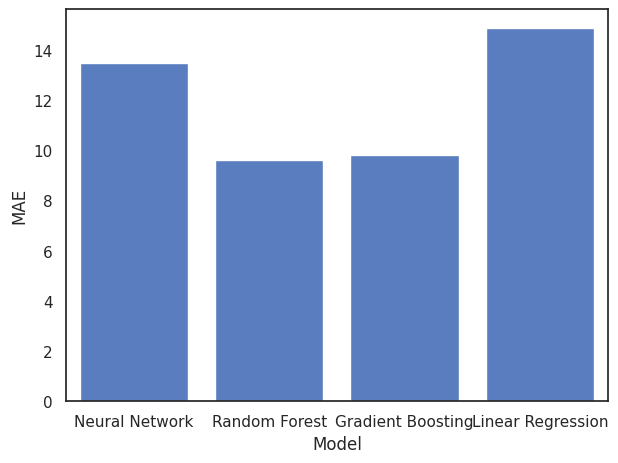

In [101]:
# Строим график значений метрики для каждой модели
sns.barplot(metrics, x="Model", y="MAE")
plt.tight_layout()
plt.show()

### Mean Squared Error

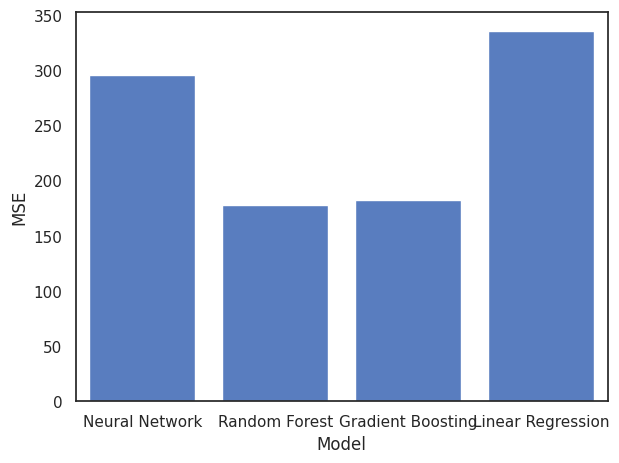

In [102]:
# Строим график значений метрики для каждой модели
sns.barplot(metrics, x="Model", y="MSE")
plt.tight_layout()
plt.show()

### Root Mean Squared Error

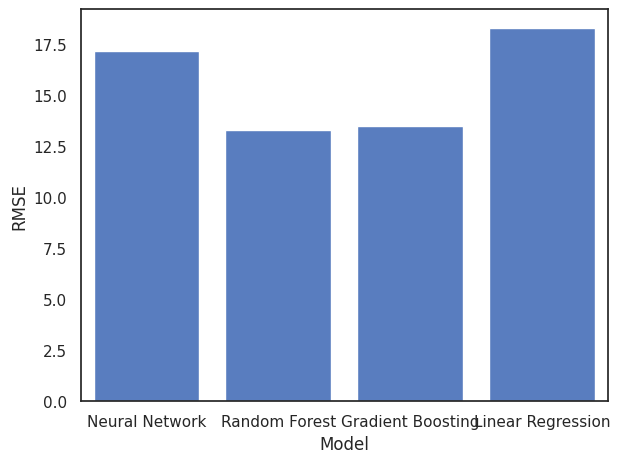

In [103]:
# Строим график значений метрики для каждой модели
sns.barplot(metrics, x="Model", y="RMSE")
plt.tight_layout()
plt.show()

### R^2 score

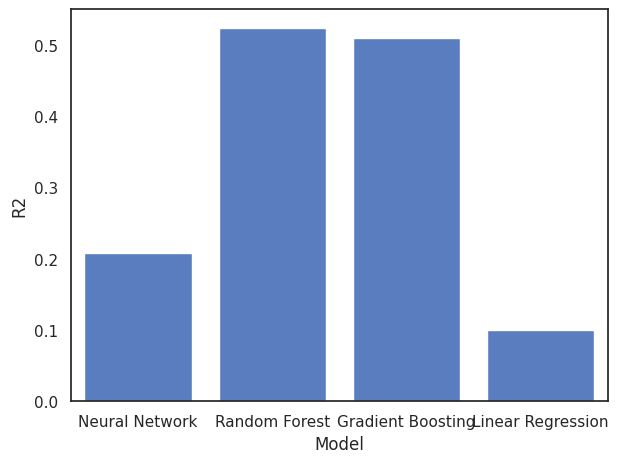

In [104]:
# Строим график значений метрики для каждой модели
sns.barplot(metrics, x="Model", y="R2")
plt.tight_layout()
plt.show()

### Mean Absolute Percentage Error

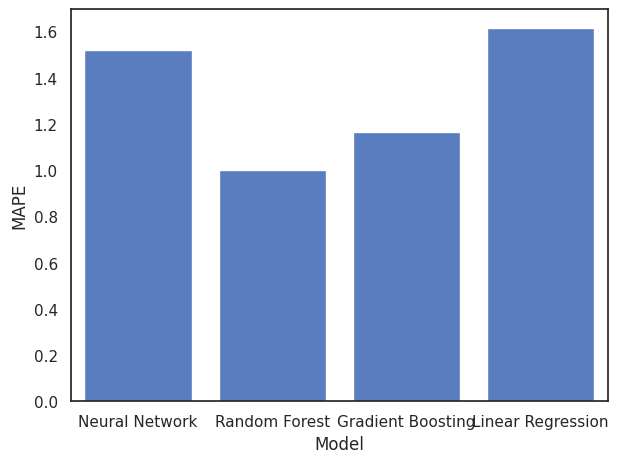

In [105]:
# Строим график значений метрики для каждой модели
sns.barplot(metrics, x="Model", y="MAPE")
plt.tight_layout()
plt.show()

Итак, после проведения сравнения метрик - получаем, что во всех случаях Random Forest с самым простым параметром здесь преимущественнее других моеделей. Модель случайного леса имеет наименьшие ошибки (меньше — лучше) и наибольший R^2 score (больше — лучше).  Были попытки улучшить результат при помощи подбора различных параметров, но это было либо безуспешно, либо значительно увеличивало время обучения.

Таким образом, останавливаемся на модели случайного леса.

### Кросс-валидация

In [108]:
# Создаём модель
model = RandomForestRegressor(random_state=42)

# Делим датасет на 5 фолдов
for i, (train_index, test_index) in enumerate(KFold(5).split(X)):
    if i:
        print()
    print(f"Fold {i + 1}")

    # Получаем выборки по индексам
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Обучаем модель
    model.fit(X_train, y_train)

    # Прогнозируем на тестовой выборке
    y_pred = model.predict(X_test)

    # Вычисляем метрики
    mae_rf = mean_absolute_error(y_test, y_pred)
    mse_rf = mean_squared_error(y_test, y_pred)
    rmse_rf = mse_rf ** 0.5
    r2_rf = r2_score(y_test, y_pred)
    mape_rf = mean_absolute_percentage_error(y_test, y_pred)

    print(f"MAE: {mae_rf}")
    print(f"MSE: {mse_rf}")
    print(f"RMSE: {rmse_rf}")
    print(f"R2: {r2_rf}")
    print(f"MAPE: {mape_rf}")

Fold 1
MAE: 15.464201197191935
MSE: 350.2212818025444
RMSE: 18.71420000434281
R2: 0.09062470552106539
MAPE: 1.6691324991371135

Fold 2
MAE: 13.78234249759307
MSE: 291.30574478627676
RMSE: 17.067681294958515
R2: 0.1503191408904473
MAPE: 1.0441457638497607

Fold 3
MAE: 21.249807064486678
MSE: 639.8412278079452
RMSE: 25.29508307572729
R2: -0.3999975169455521
MAPE: 2.9753415749884407

Fold 4
MAE: 15.992630142035289
MSE: 395.29027681293604
RMSE: 19.88190827895894
R2: -0.15110857046621895
MAPE: 1.3685777770233878

Fold 5
MAE: 14.423369745295984
MSE: 334.2665302316238
RMSE: 18.28295737104979
R2: -0.17816047840291338
MAPE: 1.5604071630717107


### **Вывод**:
В результате данной работы удалось создать модель для предсказания популярности песни.

Наша команда провела тщательный анализ датасета: было выдвинуто много гипотез и каждая была исследована. На этапе Feature Engineering нам пришлось убрать из датасета лишние данные, взамен которых были созданы новые признаки. Были созданы матрицы корреляции, выведены графики важности признаков. После чего были созданы модели различными методами, лучшим из которых себя показал случайный лес.

На этапе кросс-валидации лучший фолд имел следующие метрики:

Fold 2

MAE: 13.78234249759307

MSE: 291.30574478627676

RMSE: 17.067681294958515

R2: 0.1503191408904473

MAPE: 1.0441457638497607